# Clinical Interpretability & SHAP

**Purpose:** Walk through model interpretability, odds ratios, and local prediction explanations.

In [1]:
import pandas as pd
import os
import sys
import joblib
import shap
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath('..'))
from src.preprocessing import load_and_split_data
from src.explainability import (
    get_feature_coefficients, 
    setup_shap_explainer, 
    compute_global_shap, 
    explain_prediction
)

import warnings
warnings.filterwarnings('ignore')

### 1. Global Coefficients & Odds Ratios

Because we used Logistic Regression, we can interpret the coefficients globally via Odds Ratios ($e^\beta$).

In [2]:
# Load data and the finalized model
filepath = os.path.join("..", "data", "raw", "heart_disease_uci.csv")
X_train, X_test, y_train, y_test = load_and_split_data(filepath)
pipeline = joblib.load(os.path.join("..", "models", "saved_models", "final_model_pipeline.joblib"))

coef_df = get_feature_coefficients(pipeline)
print("Top 5 Risk-Increasing Features:")
display(coef_df[coef_df['Coefficient (β)'] > 0].head(5))

print("\nTop 5 Risk-Decreasing Features:")
display(coef_df[coef_df['Coefficient (β)'] < 0].head(5))

Top 5 Risk-Increasing Features:


,Feature,Coefficient (β),Odds Ratio,Direction of Risk
0,ca,1.125993,3.083276,Increases
1,cp_4.0,0.968677,2.634456,Increases
2,thal_7.0,0.801445,2.228758,Increases
4,sex_1.0,0.721391,2.057293,Increases
6,slope_2.0,0.609170,1.838904,Increases



Top 5 Risk-Decreasing Features:


,Feature,Coefficient (β),Odds Ratio,Direction of Risk
3,sex_0.0,-0.722601,0.485488,Decreases
5,cp_1.0,-0.649175,0.522477,Decreases
7,thal_3.0,-0.561458,0.570377,Decreases
8,slope_1.0,-0.489227,0.613100,Decreases
9,cp_3.0,-0.478354,0.619803,Decreases


### 2. Global SHAP Feature Importance

SHAP (SHapley Additive exPlanations) provides a robust framework for interpreting predictions. We initialize the explainer strictly on the training background data.

In [3]:
explainer, feature_names = setup_shap_explainer(pipeline, X_train)
global_shap_df = compute_global_shap(explainer, pipeline, X_train)

print("Top Global Features by Mean |SHAP|:")
display(global_shap_df.head(10))

Background dataset has 242 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=242 when initializing the masker.


Top Global Features by Mean |SHAP|:


,Feature,Mean |SHAP|
0,ca,0.933522
1,cp_4.0,0.483378
2,thal_7.0,0.388668
3,sex_0.0,0.316631
4,sex_1.0,0.316100
5,slope_2.0,0.300708
6,thalach,0.286642
7,thal_3.0,0.277945
8,trestbps,0.264385
9,slope_1.0,0.245018


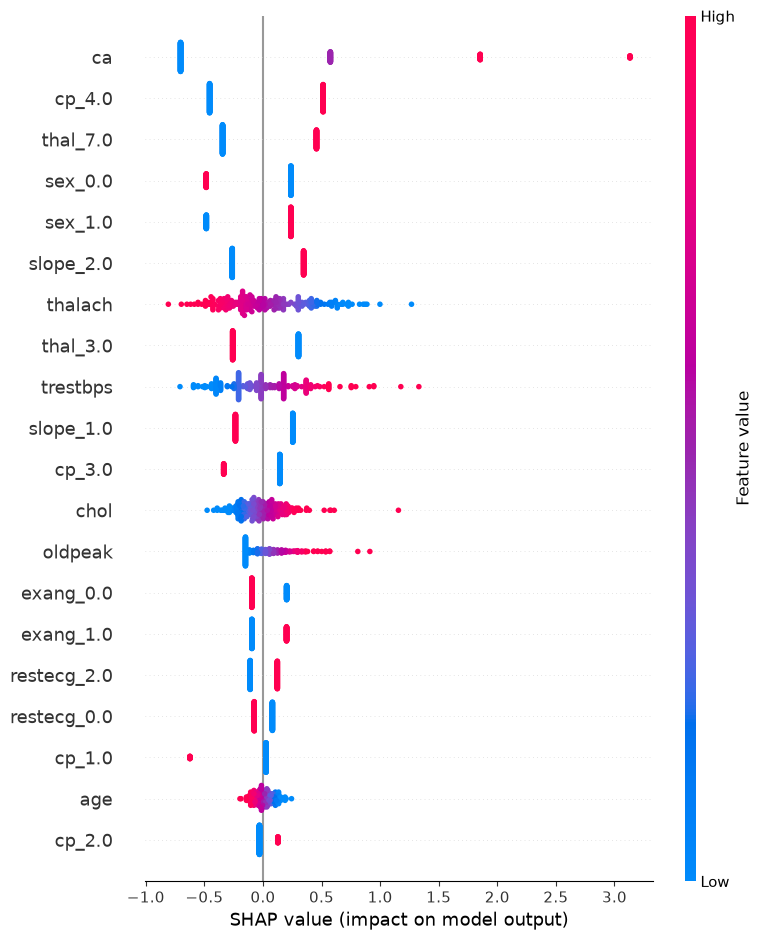

In [4]:
# SHAP Summary Plot
preprocessor = pipeline.named_steps['preprocessor']
X_train_transformed = preprocessor.transform(X_train)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

### 3. Local Sample Explanations (Test Patients)

We can explain individual predictions on the test set. Let's look at a High-Risk and Low-Risk patient.

In [5]:
# Find a True Positive (High Risk Patient)
y_pred = pipeline.predict(X_test)
tp_index = (y_test.values == 1) & (y_pred == 1)
tp_obs = X_test[tp_index].iloc[[0]]

explanation = explain_prediction(explainer, pipeline, tp_obs)
print(f"Base Log-Odds: {explanation['base_value']:.4f}")
print(f"Final Prediction Log-Odds: {explanation['total_prediction_log_odds']:.4f}")
display(explanation['shap_summary_df'].head(5))

Base Log-Odds: -0.2001
Final Prediction Log-Odds: 1.1169


,Feature,Feature Value (Transformed),SHAP Contribution,Direction
0,ca,-0.689715,-0.703179,Pushes away from disease
1,cp_4.0,1.000000,0.513399,Pushes towards disease
2,thal_7.0,1.000000,0.456823,Pushes towards disease
3,thal_3.0,0.000000,0.303187,Pushes towards disease
4,slope_2.0,0.000000,-0.261943,Pushes away from disease


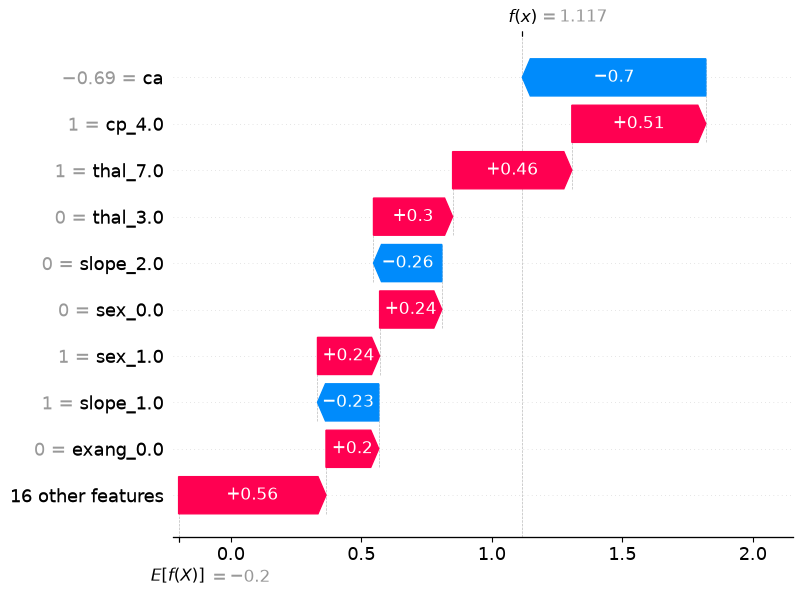

In [6]:
# SHAP Waterfall for TP Patient
# We can visualize this using standard shap library waterfall plot
shap_explanation = shap.Explanation(
    values=explainer.shap_values(preprocessor.transform(tp_obs))[0], 
    base_values=explainer.expected_value, 
    data=preprocessor.transform(tp_obs)[0], 
    feature_names=feature_names
)
shap.waterfall_plot(shap_explanation)

### Discussion

It is critical to note the difference between **statistical correlation**, **model importance (SHAP)**, and **causal clinical diagnosis**. 

Features like `ca` (number of major vessels) are highly predictive in this model (high correlation and high SHAP values), but machine learning models capture associations, not direct causation. This highlights why explainable AI must be paired with domain expertise (a cardiologist) rather than deployed as an autonomous diagnostic tool.